# Umělé neuronové sítě typu MLP


## Data

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def show_loss(iterations, loss, epoch=False):
    plt.plot(iterations, loss)
    plt.xlabel("Epocha" if epoch else "Iterace")
    plt.ylabel("Loss")
    plt.title("Průběh trénování")
    plt.show()

npzfile = np.load('data/data_10.npz')
npzfile.files


['x', 'xTest', 'y', 'yTest', 'w1', 'w2']

In [2]:
x = npzfile['x']
xTest = npzfile['xTest']

y = npzfile['y']
yTest = npzfile['yTest']

print(f"{x.shape=}")
print(f"{y.shape=}")
print(f"Počet tříd: {np.max(y) + 1}") 

w1test = npzfile['w1']
w2test = npzfile['w2']

x.shape=(4500, 400)
y.shape=(4500, 1)
Počet tříd: 10


## Stavební bloky sítě

### Funkce sigmoid

$$ sigmoid(u) = \sigma (u) = \frac{e^u}{1+e^u} = \frac{1}{1+e^{-u}} $$


In [3]:
def sigmoid(u):
    #################################################################
    # ZDE DOPLNIT
    return 1 / (1 + np.exp(-u))
    #################################################################


In [22]:
#Kontrola:
u = np.array([[1,2],[-3,-4]])
sigmoid(u)

array([[0.73105858, 0.88079708],
       [0.04742587, 0.01798621]])

#### Derivace funkce sigmoid:
$$ \sigma' (u) = \sigma (u) (1 - \sigma(u)) $$

In [23]:
def sigmoid_grad(u):
    
    #################################################################
    # ZDE DOPLNIT
    return sigmoid(u) * (1 - sigmoid(u))
    #################################################################


In [24]:
#Kontrola:
sigmoid_grad(u)

array([[0.19661193, 0.10499359],
       [0.04517666, 0.01766271]])

### ReLU

$$ f(u) = max(0, u) $$



In [25]:
def relu(u):
    #################################################################
    # ZDE DOPLNIT
    return np.maximum(0, u)
    #################################################################


In [26]:
#Kontrola:
relu(u)

array([[1, 2],
       [0, 0]])

#### Derivace funkce ReLU:
$$ f'(x) = \boldsymbol{1} (x \ge 0)$$

Derivace přímo v bodě nula je dodefinována na hodnotu nula.

Gradient se přes tento blok přenáší:
1) Nezměněný, pokud je hodnota na vstupu z dopředného průchodu větší než nula.
2) Přenesená hodnota je nula, pokud je hodnota na vstupu z dopředného průchodu menší nebo rovna nule.

In [27]:
def relu_grad(u):
    #################################################################
    # ZDE DOPLNIT
    return (u > 0)
    #################################################################


In [28]:
#Kontrola:
relu_grad(u)

array([[ True,  True],
       [False, False]])

### One Hot Encoding
$ \pi $ nabývá hodnoty 1 pouze pro jednu třídu. Např. máme celkem 3 třídy (0, 1, 2): $\pi_0 = [0,1,0]$  pro $y_0 = 1$


$$
    classes = 
        \begin{bmatrix}
        1 \\
        0 \\
        2\\
        1 \\
        \end{bmatrix} 
    \implies
        \pi = 
        \begin{bmatrix}
        0 & 1 & 0 \\
        1 & 0 & 0 \\
        0 & 0 & 1 \\
        0 & 1 & 0 \\
        \end{bmatrix} 
$$

In [29]:
def one_hot_encoding(data):
    #################################################################
    # ZDE DOPLNIT
    data = data.astype(int)
    classes = np.max(data) + 1
    onehot = np.zeros((data.shape[0], classes))
    onehot[np.arange(data.shape[0]), data.T] = 1
    return onehot
    #################################################################


In [30]:
#Kontrola:
encoded = one_hot_encoding(y)
encoded[[0,900,1800,2700,3500,4200],:]

array([[0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.]])

### Softmax

- Funkce softmax má c vstupů a c výstupů. 
- Všechny výstupy jsou kladná čísla. 
- Součet všech výstupů dohromady je roven číslu 1.
$$\widehat{y_c} = softmax(u) = \frac{e^{u_c}}{\sum_{d=0}^{c} {e^{u_d}}} $$


In [31]:
def softmax(u):
    """
    softmax !radkove!
    """
    #################################################################
    # ZDE DOPLNIT
    return np.exp(u) / np.sum(np.exp(u), axis=1, keepdims=True)
    #################################################################


In [32]:
#Kontrola:
softmax(u)

array([[0.26894142, 0.73105858],
       [0.73105858, 0.26894142]])

In [109]:
def theta_grad(grad_on_output, input_data):
    #################################################################
    # ZDE DOPLNIT
    weight_grad = input_data.T @ grad_on_output / input_data.shape[0]
    bias_grad = np.sum(grad_on_output, axis=0, keepdims=True)[0] / input_data.shape[0]
    #################################################################
    return weight_grad.T, bias_grad

In [89]:
#test vypoctu gradientu pro matici vah a biasy

#dva vstupni vektory, kazdy ma 4 hodnoty, cili jde o vrstvu, kde kazdy neuron ma 4 vstupy
input_test = np.array([[7,8,4,1],[9,10,4,2]])
print("input_test")
print(input_test.shape)

#dva gradienty na vystupu, kazdy ma 3 hodnoty, cili jde o vrstvu, ktera ma 3 neurony [a kazdy ma 4 vstupy])
grad_on_output_test = np.array([[1,2,3],[4,2,6]])
print("grad_on_output_test")
print(grad_on_output_test.shape)

w_grad_test,u_grad_test = theta_grad(grad_on_output_test,input_test)

#gradienu vektoru vah ma tedy rozmery 3*4
print("w_grad_test")
print(w_grad_test.shape)
print(w_grad_test)

#gradient biasu ma 3 hodnoty
print("u_grad")
print(u_grad_test.shape)
print(u_grad_test)

input_test
(2, 4)
grad_on_output_test
(2, 3)
w_grad_test
(3, 4)
[[43 48 20  9]
 [32 36 16  6]
 [75 84 36 15]]
u_grad
(3,)
[5 4 9]


## Sítě typu vícevrstvý perceptron = Multi-Layer Perceptron (MLP)



### Předzpracování dat
Pro trénování neuronových sítí je vhodné provádět standardizaci dat na nulovou střední hodnotu a jednotkový rozptyl.

### Inicializace parametrů (váhových koeficientů)
- Váhy neuronů nesmí být nastaveny na stejné hodnoty (např. 0), aby neměly stejnou hodnotu výstupu a stejný gradient
=>
- Je třeba porušit symetrii:
    - Váhy se inicializují jako malá náhodná čísla (polovina kladná, polovina záporná)
    - V praxi se pro ReLU používá hodnota $randn(n) * sqrt(2.0/n)$, kde n je počet vstupů neuronu
    - Započítání počtu vstupů pak zajišťuje, že neurony s různým počtem vstupů mají výstup se stejným rozptylem hodnot
    - Biasy se inicializují na hodnotu 0 nebo 0.01 (symetrie je již porušena inicializací váhových koeficientů)

### Dopředný průchod
Kroky:
1. $x_1$ je $x$ rozšířená o sloupec bias
2. $u_1 = \theta_1^T x_1$ (vstupní vrstva)
3. $a_1 = ReLU(u_1)$ (aktivační funkce, v kódu použijte obecně `activation_function`)
4. $x_2$ je $a_1$ rozšířená o sloupec bias
5. $u_2 = \theta_2^T x_2$ (skrytá vrstva)
6. $\tilde{y} = softmax(u_2)$ (výstupní vrstva)

Na výstupu vznikne podle zvoleného kritéria chyba či odchylka.

### Zpětný průchod

(Hodnoty z dopředného průhodu $x$, $a_1$ a $u_2$ je vhodné si z dopředného průchodu uložit.)

1. $du_2 = softmax(u_2)-\pi(y)$

2. $dW_2 = du_2 a_1^T$  a  $db_2 = du_2 $

3. $da_1 = W_2^T du_2$

4. $du_1 = da_1 \odot relu'(du_1)$ (v kódu použijte obecně `activation_function_derivation`)

5. $dW_1 = du_1^T x$  a  $db = du_1 $

In [118]:
class TwoLayerPerceptron:
    def __init__ (self, *, input_layer_size, hidden_layer_size, output_size, activation_function, activation_function_derivation):
        #################################################################
        # ZDE DOPLNIT
        self.w1 = np.random.randn(input_layer_size + 1, hidden_layer_size).T * np.sqrt(2/(input_layer_size * hidden_layer_size))
        print(f"w1 shape: {self.w1.shape}")
        # null bias
        # self.w1[:, 0] = 0
        self.w2 = np.random.randn(hidden_layer_size + 1, output_size).T * np.sqrt(2/(hidden_layer_size * output_size)) * 0.1
        # self.w2[:, 0] = 0
        print(f"w1 max: {np.max(self.w1)}, w1 min: {np.min(self.w1)}")
        print(f"w2 max: {np.max(self.w2)}, w2 min: {np.min(self.w2)}")

        self.activation_function = activation_function
        self.activation_function_derivation = activation_function_derivation
        
        #################################################################
        
    def forward(self, x) -> tuple[np.ndarray, dict]:
        """
        Spočítá predikci na základě aktuálních vah.
        """

        #################################################################
        # ZDE DOPLNIT

        #1. vrstva
        #nezapomente na bias(prvni sloupec) #4500x401
        x1 = np.c_[np.ones((x.shape[0],1)), x]
        # print(f"x shape: {x1.shape}")
        # print(f"x1: {x1[0, 0:4]}")
        # print(f"w1 shape: {self.w1.shape}")
        u1 = x1 @ self.w1.T
        
        # print(f"u1: {u1[0, 0:4]}")

        #aktivacni funkce pomocí funkce self.activation_function
        a1 = self.activation_function(u1) #4500x25
        # print(f"a1: {a1[0, 0:4]}")

        #2. vrstva (skryta vrstva)
        x2 = np.c_[np.ones((a1.shape[0],1)), a1] #4500x26
        # print(f"x2: {x2[0, 0:4]}")
        u2 = x2 @ self.w2.T
        # print(f"u2: {u2[0, 0:4]}")

        #vystup po softmaxu
        scores = softmax(u2) #4500x10 scores pro kazdou tridu            
        # print(f"scores: {scores[0, 0:4]}")
        
        #cache
        forward_cache = {
            'x1': x1,
            'u1': u1,
            'a1': a1,
            'x2': x2,
            'u2': u2,
            'scores': scores
        }
        #################################################################
        
        # forward_cache je dictionary obsahující uložené hodnoty potřebné pro zpětný průchod
        return scores, forward_cache
    
    def backward(self, classes, forward_cache: dict) -> dict:
        """
        Vypočítá gradienty na základě hodnot uložených při dopředném průchodu.
        """

        #################################################################
        # ZDE DOPLNIT

        #pomocí self.scores, self.classes a one_hot_encoding 
        du2 = forward_cache['scores'] - one_hot_encoding(classes)
        # print(f"du2: {du2[0, 0:4]}")
        
        #pomocí funkce theta_grad
        dw2, db2 = theta_grad(du2, forward_cache['x2'])
        #print(dw2[:, :1], db2)
        dw2 = dw2[:, 1:] #removes bias column, bias is db2
        # print(f"dw2: {dw2[0, 0:4]}")
        # print(f"db2: {db2[0:4]}")
        
        w2_no_bias = self.w2[:, 1:]
        da1 = du2 @ w2_no_bias
        
    #da1 = da1[1:, :]
        # print(f"da1: {da1[0, 0:4]}")
        
        #pomocí funkce self.activation_function_derivation
        #POZOR: tato funce se musí aplikovat na vstupní hodnotu z dopředného průchodu !!
        du1 = self.activation_function_derivation(forward_cache['u1']) * da1
        # print(f"du1: {du1[0, 0:4]}")
        
        #pomocí funkce theta_grad
        dw1, db1 = theta_grad(du1, forward_cache['x1'])
        #dw1 = dw1[:, 1:]
        # print(f"dw1: {dw1[0, 0:4]}")
        # print(f"db1: {db1[0:4]}")
        
        gradients = {
            'dw1': dw1,
            'db1': db1,
            'dw2': dw2,
            'db2': db2
        }
        #################################################################

        # gradients je dictionary obsahující vypočtené gradienty
        return gradients


    def update_weights_gd(self, gradients: dict, alpha, lmbd=0):
        """
        Aktualizuje váhy sítě na základě vypočtených gradientů.
        """

        #################################################################
        # ZDE DOPLNIT
    
        #POZOR: dw2 není gradient celé matice w2 ale pouze její části
        #gradient celé matice w2 pro update vah vznikne vhodným spojením dw2 a db2
        dw2_full = np.c_[gradients['db2'], gradients['dw2']]
        self.w1 -= alpha * (gradients['dw1'] + lmbd * self.w1)
        # print(f"w1: {self.w1[0, 0:4]}")
        self.w2 -= alpha * (dw2_full + lmbd * self.w2)
        # print(f"w2: {self.w2[0, 0:4]}")
        # print(gradients['dw1'].shape, self.w1.shape)
        # print(dw2_full.shape, self.w2.shape)
        
        #################################################################
    

    def accuracy(self, x, classes):
        #################################################################
        # ZDE DOPLNIT
        return np.mean(np.argmax(self.forward(x)[0], axis=1) == classes)
        #################################################################
            


In [119]:
input_layer_size = 400
hidden_layer_size = 25
output_size = len(np.unique(y))


In [104]:
#Instance pro odladění:
testTlp = TwoLayerPerceptron(input_layer_size=input_layer_size, hidden_layer_size=hidden_layer_size, output_size=output_size, activation_function=sigmoid, activation_function_derivation=sigmoid_grad)
testTlp.w1 = w1test
testTlp.w2 = w2test
# alpha = 0.0005, lmbd=0

test_scores, test_cache = testTlp.forward(x)
test_gradients = testTlp.backward(y, test_cache)
testTlp.update_weights_gd(test_gradients, alpha=0.0005)

w1 shape: (25, 401)
w1 max: 0.05300882259401514, w1 min: -0.05014877857922517
w2 max: 0.02761550742575511, w2 min: -0.024864356586868103
w1 shape: (25, 401)
(25, 401) (25, 401)
(10, 26) (10, 26)


Data pro odladění s předchozí instancí po jednom kroku trénování:

In [106]:
def train_gd(model, x, classes, nIter, alpha=0.00015, lmbd=0):
    """
    Natrénuje síť a vykreslí graf vývoje lossu.
    """

    # Na konci každé iterace vypočtěte cross-entropy loss a ulože ho na odpovídající index v poli.
    loss = np.zeros(nIter)

    #################################################################
    # ZDE DOPLNIT  
    xlen = x.shape[0]
    print(f"x max value: {np.max(x)}, x min value: {np.min(x)}")
    xarang = np.arange(xlen)
    for i in range(nIter):
        scores, cache = model.forward(x)

        log_likelihood = -np.log(scores[xarang, classes])
        loss[i] = np.sum(log_likelihood) / xlen

        gradients = model.backward(classes, cache)
        model.update_weights_gd(gradients, alpha, lmbd)
    #################################################################

    show_loss(np.arange(nIter), loss)

Trénování modelu s aktivační funkcí sigmoid:

w1 shape: (25, 401)
w1 max: 0.05960113684088738, w1 min: -0.05477317513849437
w2 max: 0.03600950887134883, w2 min: -0.031967104106703295
x max value: 1.127688299158888, x min value: -0.13196323019852488
w1 shape: (25, 401)
w1 shape: (25, 401)
w1 shape: (25, 401)
w1 shape: (25, 401)
w1 shape: (25, 401)
w1 shape: (25, 401)
w1 shape: (25, 401)
w1 shape: (25, 401)
w1 shape: (25, 401)
w1 shape: (25, 401)
w1 shape: (25, 401)
w1 shape: (25, 401)
w1 shape: (25, 401)
w1 shape: (25, 401)
w1 shape: (25, 401)
w1 shape: (25, 401)
w1 shape: (25, 401)
w1 shape: (25, 401)
w1 shape: (25, 401)
w1 shape: (25, 401)
w1 shape: (25, 401)
w1 shape: (25, 401)
w1 shape: (25, 401)
w1 shape: (25, 401)
w1 shape: (25, 401)
w1 shape: (25, 401)
w1 shape: (25, 401)
w1 shape: (25, 401)
w1 shape: (25, 401)
w1 shape: (25, 401)
w1 shape: (25, 401)
w1 shape: (25, 401)
w1 shape: (25, 401)
w1 shape: (25, 401)
w1 shape: (25, 401)
w1 shape: (25, 401)
w1 shape: (25, 401)
w1 shape: (25, 401)
w1 shape: (25, 401)
w1 shape: (25, 40

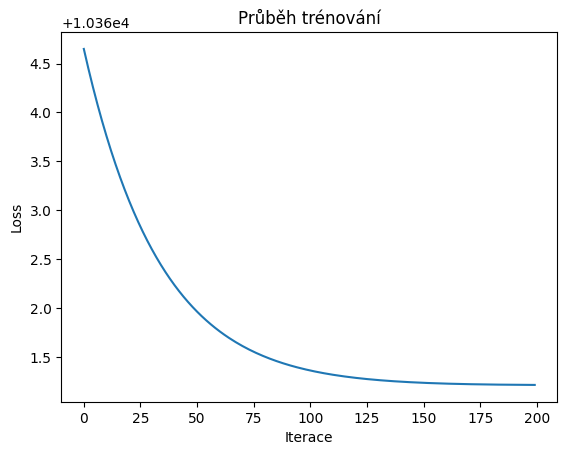

w1 shape: (25, 401)
sigmoid testovaci mnozina : 0.078192


In [117]:
tlp = TwoLayerPerceptron(input_layer_size=input_layer_size, hidden_layer_size=hidden_layer_size, output_size=output_size, activation_function=sigmoid, activation_function_derivation=sigmoid_grad)
#################################################################
# ZDE DOPLNIT
train_gd(tlp, x, y, nIter=200, alpha=0.02)
accuracy = tlp.accuracy(xTest, yTest)
#################################################################
print(f"sigmoid testovaci mnozina : {accuracy}") 

Trénování modelu s aktivační funkcí ReLU:

w1 shape: (25, 401)
w1 max: 0.05373461348487341, w1 min: -0.04884541239620908
w2 max: 0.023008159796746204, w2 min: -0.02203230721801421
x max value: 1.127688299158888, x min value: -0.13196323019852488


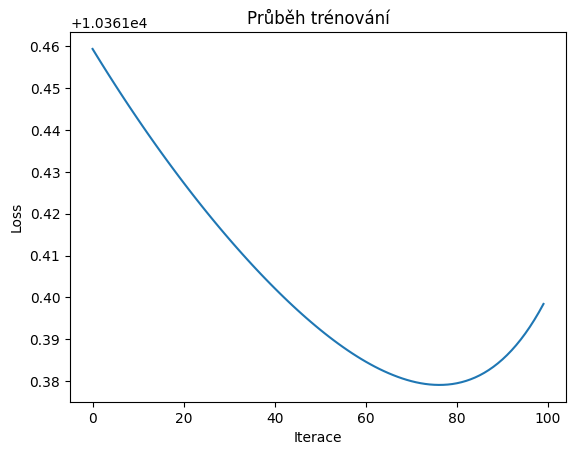

relu testovaci mnozina : 0.080488


In [122]:
tlp = TwoLayerPerceptron(input_layer_size=input_layer_size, hidden_layer_size=hidden_layer_size, output_size=output_size, activation_function=relu, activation_function_derivation=relu_grad)
#################################################################
# ZDE DOPLNIT
train_gd(tlp, x, y, nIter=100, alpha=0.03)
accuracy = tlp.accuracy(xTest, yTest)
#################################################################
print(f"relu testovaci mnozina : {accuracy}")

# Bonus: PyTorch a MNIST

Data: Číslovky z datasetu MNIST z bonusové části 7. cvičení (tam si je můžete prohlédnout).

**Dosáhněte accuracy > 97 %**

Tip: Menší batche napomáhají generalizaci.

In [123]:
import torch
import torch.nn as nn
import torch.optim as optim

In [124]:
npzfile = np.load('data/data_07_mnist_train.npz') 

data = npzfile['data']
ref = npzfile['ref']

# Převod na objekty knihovny PyTorch
data = torch.Tensor(data)
ref = torch.Tensor(ref).long()

In [125]:
npzfile = np.load('data/data_07_mnist_test.npz') 

test_data = npzfile['data']
test_ref = npzfile['ref']

# Převod na objekty knihovny PyTorch
test_data = torch.Tensor(test_data)
test_ref = torch.Tensor(test_ref).long()

In [126]:
# Normalizace hodnot pixelů (na základě statistických odhadů z trénovacích dat)
mean = data.mean()
std = data.std()
data = (data - mean) / std
test_data = (test_data - mean) / std

Sequential(
  (0): Linear(in_features=784, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=10, bias=True)
)
Epoch [1/50], Loss: 0.2892
Epoch [2/50], Loss: 0.1251
Epoch [3/50], Loss: 0.0873
Epoch [4/50], Loss: 0.0667
Epoch [5/50], Loss: 0.0533
Epoch [6/50], Loss: 0.0416
Epoch [7/50], Loss: 0.0350
Epoch [8/50], Loss: 0.0287
Epoch [9/50], Loss: 0.0240
Epoch [10/50], Loss: 0.0206
Epoch [11/50], Loss: 0.0174
Epoch [12/50], Loss: 0.0152
Epoch [13/50], Loss: 0.0135
Epoch [14/50], Loss: 0.0125
Epoch [15/50], Loss: 0.0089
Epoch [16/50], Loss: 0.0109
Epoch [17/50], Loss: 0.0078
Epoch [18/50], Loss: 0.0091
Epoch [19/50], Loss: 0.0122
Epoch [20/50], Loss: 0.0081
Epoch [21/50], Loss: 0.0056
Epoch [22/50], Loss: 0.0055
Epoch [23/50], Loss: 0.0078
Epoch [24/50], Loss: 0.0078
Epoch [25/50], Loss: 0.0074
Epoch [26/50], Loss: 0.0056
Epoch [27/50], Loss: 0.0072
Epoch [28/50], Loss: 0.0070
Epoch [29/50], Loss: 0.0047
Epoch [30/50], Loss: 0.0040
Epoch [31/50], Loss: 0

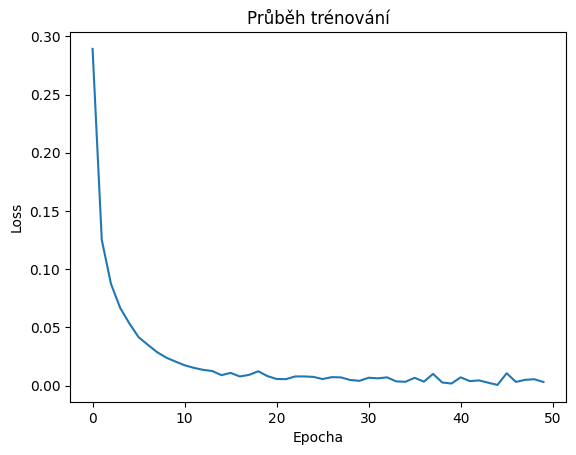

In [128]:
# Definice modelu

#################################################################
# ZDE DOPLNIT
input_layer_size = 784
hidden_layer_size = 128
output_size = 10
#################################################################

model = nn.Sequential(
    nn.Linear(input_layer_size, hidden_layer_size),
    nn.ReLU(),
    nn.Linear(hidden_layer_size, output_size),
    # SOFTMAX se nepřidává! Kriteriální funkce ho počítá sama. Výstupem sítě jsou tzv. logity.
)

print(model)

# Konfigurace hyperparametrů trénování.
# Optimizér provádí zvolenou metodu optimalizace sítě (SGD / SGD + momentum / ADAM / jiné).
# Parametr weight_decay je lmbd z našeho kódu.
#################################################################
# ZDE DOPLNIT
num_epochs = 50
batch_size = 100
optimizer = optim.SGD(model.parameters(), lr=0.01, weight_decay=0.001, momentum=0.9)
# optimizer = optim.Adam(...)
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.001)
#################################################################

# Kriteriální funkce: počítá softmax a cross-entropy loss.
criterion = nn.CrossEntropyLoss()

# Nastaví model do trénovacího módu (důležité pro některé typy vrstev, např. Dropout nebo BatchNorm).
model.train()

losses = np.zeros(num_epochs)
num_batches = data.size(0) // batch_size

for epoch in range(num_epochs):
    # Zamíchání dat
    permutation = torch.randperm(data.size(0))
    
    epoch_loss = 0.0
    
    # Smyčka přes minibatche
    for i in range(0, data.size(0), batch_size):
        indices = permutation[i : i + batch_size]
        batch_x, batch_y = data[indices], ref[indices]
        
        # Gradienty jsou uloženy u vah, kterých se týkají. Je potřeba je v každé iteraci explicitně vynulovat, jinak se akumulují.
        optimizer.zero_grad()
        
        # Ekvivalent naší funkce forward (bez softmax).
        logits = model(batch_x)
        
        # Výpočet průměrného lossu podle zvolené kriteriální funkce.
        loss = criterion(logits, batch_y)
        
        # Spočítá gradienty. Ty nejsou výstupem funkce, ale jsou uloženy u vah, kterých se týkají.
        loss.backward()
        
        # Aktualizuje váhy podle zvolené metody.
        optimizer.step()
        
        epoch_loss += loss.item()

    # Průměrný loss.
    losses[epoch] = epoch_loss / num_batches
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {losses[epoch]:.4f}")

show_loss(np.arange(num_epochs), losses, epoch=True)

In [129]:
# Nastaví model do testovacího módu (důležité pro některé typy vrstev, např. Dropout nebo BatchNorm).
model.eval()

# torch.no_grad() vypne operace pro výpočet gradientu, které se provádí na pozadí, protože je zde nepotřebujeme.
with torch.no_grad():
    logits = model(test_data)
    predicted_classes = logits.argmax(1)
    acc = (predicted_classes == test_ref).float().mean()

print(f"Accuracy: {acc * 100}%")

Accuracy: 97.69999694824219%
